## 1. Kütüphanelerin Yüklenmesi ve Veri Hazırlığı


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Verileri yükleyelim
train_df = pd.read_csv('/content/DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('/content/DailyDelhiClimateTest.csv')

# Tarih sütununu datetime formatına çevirelim
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

print("Eğitim Verisi İlk 5 Satır:")
display(train_df.head())

Eğitim Verisi İlk 5 Satır:


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### 2. Ortalama Sıcaklık (meantemp) Görselleştirmesi

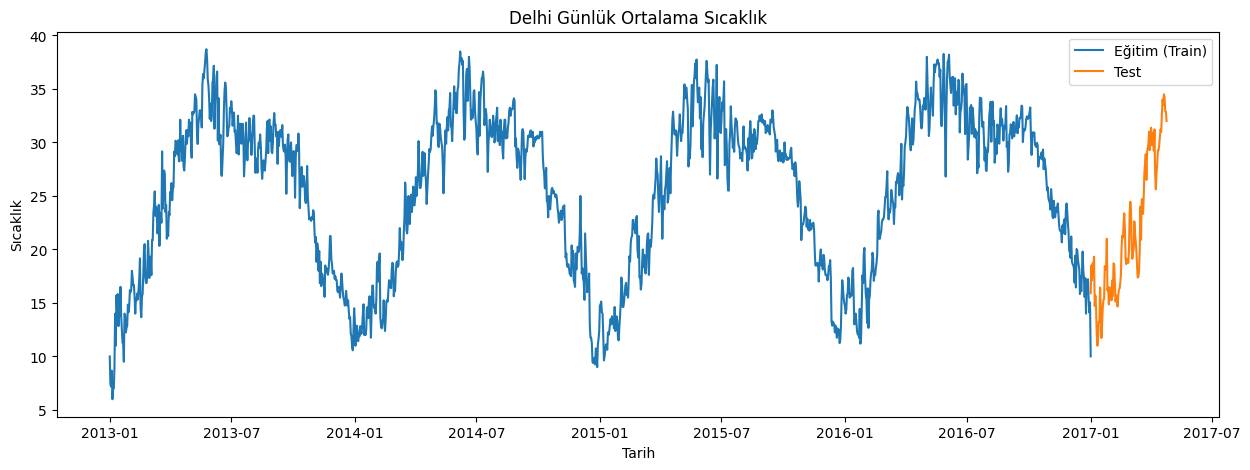

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(train_df['date'], train_df['meantemp'], label='Eğitim (Train)')
plt.plot(test_df['date'], test_df['meantemp'], label='Test')
plt.title('Delhi Günlük Ortalama Sıcaklık')
plt.xlabel('Tarih')
plt.ylabel('Sıcaklık')
plt.legend()
plt.show()

## 3. Veri Ön İşleme


In [9]:
# Sadece 'meantemp' sütununu kullanacağız
train_data = train_df[['meantemp']].values
test_data = test_df[['meantemp']].values

# Normalizasyon (0-1 arası)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Zaman pencereleri oluşturma fonksiyonu
def create_dataset(dataset, look_back=30):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 30 # Son 30 güne bakarak bir sonraki günü tahmin et
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# RNN girişi için [örnek sayısı, zaman adımı, özellik sayısı] formatına getirme
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")

X_train shape: (1432, 30, 1)


## 4. Model Oluşturma ve Eğitim


In [10]:
model = Sequential([
    SimpleRNN(units=50, activation='tanh', input_shape=(look_back, 1)),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Modeli eğitelim
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0533 - val_loss: 0.0031
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - val_loss: 0.0063
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0064 - val_loss: 0.0036
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 0.0038
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0045 - val_loss: 0.0026
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0044 - val_loss: 0.0026
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 12/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039 - val_l

## 4. Tahmin ve Sonuçların Değerlendirilmesi


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


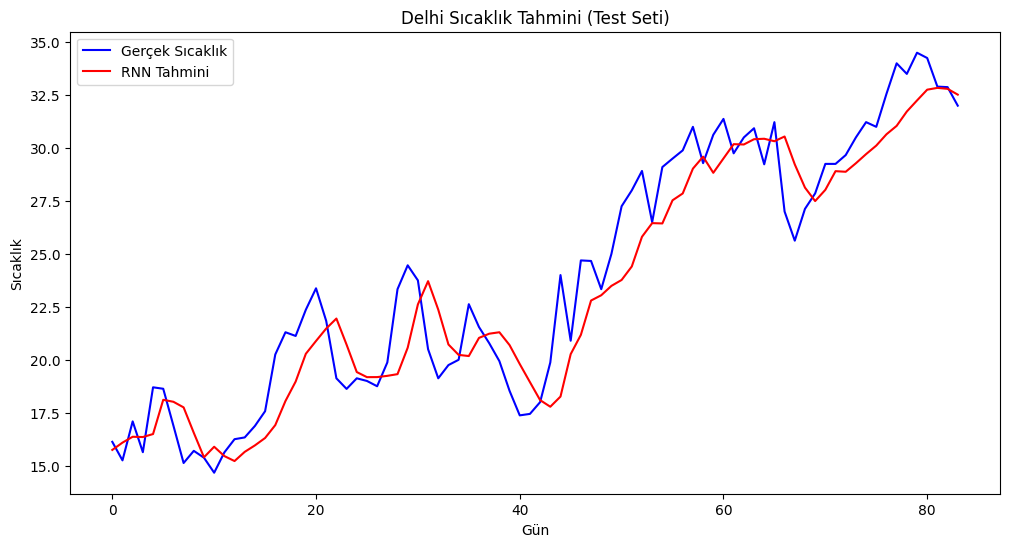

In [11]:
# Tahminleri yapalım
predictions = model.predict(X_test)

# Normalizasyonu geri alalım
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Sonuçları görselleştirelim
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, color='blue', label='Gerçek Sıcaklık')
plt.plot(predictions_rescaled, color='red', label='RNN Tahmini')
plt.title('Delhi Sıcaklık Tahmini (Test Seti)')
plt.xlabel('Gün')
plt.ylabel('Sıcaklık')
plt.legend()
plt.show()

## 5. Model Eğitim Geçmişinin Görselleştirilmesi


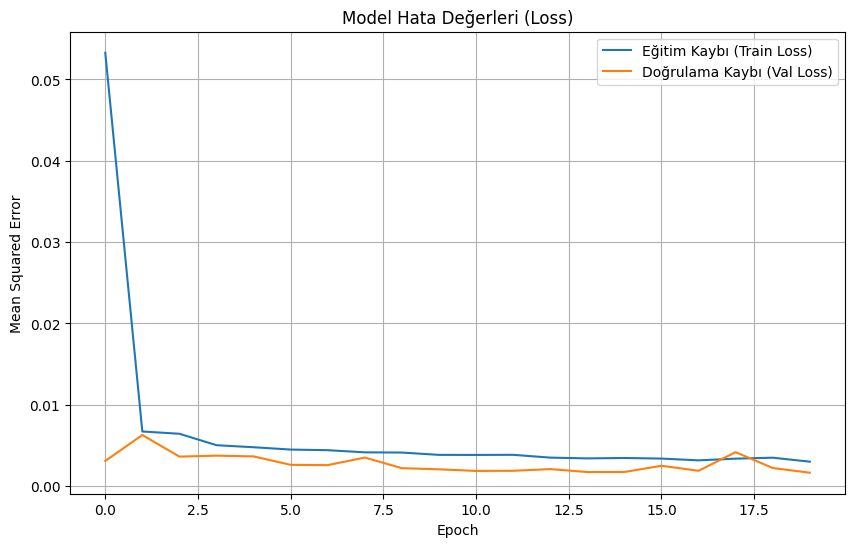

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Hata Değerleri (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()